Variable independiente (X): Solicitudes Generadas, Variable dependiente (Y):Solicitudes Formalizadas

### 1. Cargar el archivo crudo (sin encabezado, trae varias tablas pegadas)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

raw = pd.read_csv('SDC.csv', header=None, encoding='utf-8-sig')
raw.shape

(54, 37)

### 2. Extraer las variables mensuales del bloque principal (Solicitudes de Crédito)

In [2]:
# filas donde vive cada variable dentro del CSV crudo
filas_sdc = {
    'Generadas': 5, 'Aprobadas': 6, 'Condicionadas': 7,
    'Rechazadas': 8, 'Formalizadas': 9,
}
filas_pct = {'Pct_Aprobacion': 11, 'Pct_Formalizacion': 12}

n_meses = 31  # de Enero 2024 a Julio 2026

data = {}
for nombre, fila in filas_sdc.items():
    data[nombre] = raw.iloc[fila, 1:1+n_meses].tolist()
for nombre, fila in filas_pct.items():
    data[nombre] = raw.iloc[fila, 1:1+n_meses].tolist()

dfs = pd.DataFrame(data)
dfs.head()

,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,Pct_Aprobacion,Pct_Formalizacion
0,5,1,0,4,1,20%,100%
1,6,2,0,4,1,33%,50%
2,11,7,1,4,5,64%,71%
3,23,14,0,9,11,61%,79%
4,26,8,4,14,3,31%,38%


### 3. Construir Año y Mes
*Nota: el encabezado original del archivo trae un error de captura (repite "Diciembre, 25" dos veces), así que en vez de leer los nombres de mes del archivo, los generamos nosotros de forma secuencial empezando en Enero 2024.*

In [3]:
fechas = pd.date_range('2024-01-01', periods=n_meses, freq='MS')
dfs.insert(0, 'Año', fechas.year)
dfs.insert(1, 'Mes', fechas.month)
dfs[['Año','Mes']].head()

,Año,Mes
0,2024,1
1,2024,2
2,2024,3
3,2024,4
4,2024,5


### 4. Tratar columnas a tipo numérico (quitar % y comas)

In [4]:
cols_num = list(filas_sdc.keys()) + list(filas_pct.keys())

for c in cols_num:
    dfs[c] = (dfs[c].astype(str).str.replace('%', '', regex=False)
                     .str.replace(',', '', regex=False).str.strip())
    dfs[c] = pd.to_numeric(dfs[c], errors='coerce')

dfs.isna().sum()  # esta base no trae nulos: todos los meses tienen dato capturado

Año                  0
Mes                  0
Generadas            0
Aprobadas            0
Condicionadas        0
Rechazadas           0
Formalizadas         0
Pct_Aprobacion       0
Pct_Formalizacion    0
dtype: int64

### 5. Outliers con IQR (capado)

In [5]:
for c in cols_num:
    Q1, Q3 = dfs[c].quantile(0.25), dfs[c].quantile(0.75)
    IQR = Q3 - Q1
    dfs[c] = dfs[c].clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR)

dfs.to_csv('SDC_Depurado.csv', index=False)
dfs.describe()

,Año,Mes,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,Pct_Aprobacion,Pct_Formalizacion
count,31.00000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,2024.83871,5.935484,72.935484,29.483871,16.387097,23.443548,14.419355,41.483871,50.080645
std,0.77875,3.405246,35.974932,13.928079,13.290792,12.748809,7.107621,10.868520,11.341551
min,2024.00000,1.000000,5.000000,1.000000,0.000000,4.000000,1.000000,20.000000,27.000000
25%,2024.00000,3.000000,49.000000,22.000000,3.500000,13.500000,10.000000,33.500000,44.000000
50%,2025.00000,6.000000,79.000000,31.000000,17.000000,25.000000,16.000000,39.000000,48.000000
75%,2025.00000,8.500000,98.000000,40.500000,25.500000,30.000000,19.000000,47.500000,56.500000
max,2026.00000,12.000000,136.000000,51.000000,49.000000,54.750000,25.000000,64.000000,75.250000


### 6. Correlación entre las variables de SDC (punto 5)

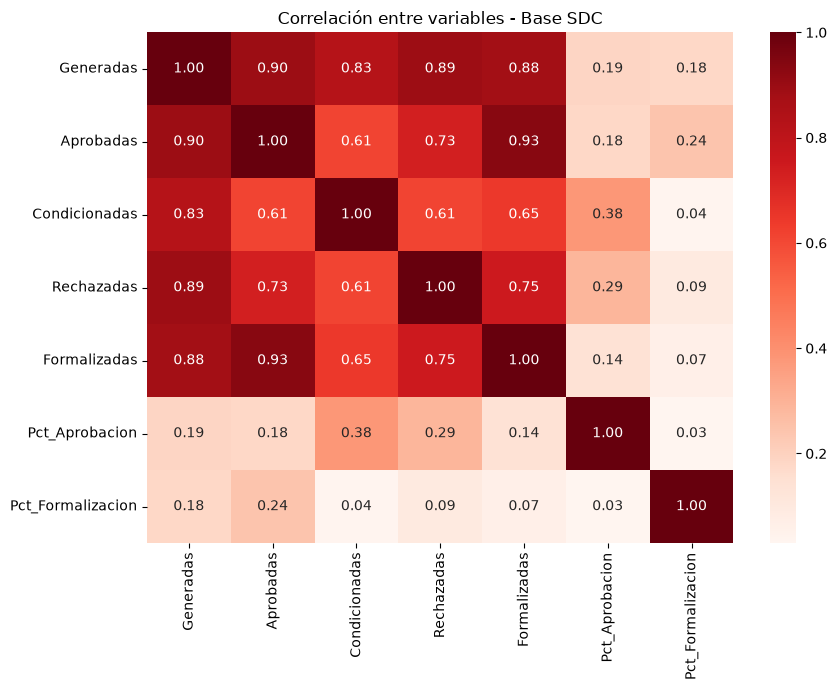

In [6]:
Corr_SDC = abs(dfs[cols_num].corr())

plt.figure(figsize=(9,7))
sns.heatmap(Corr_SDC, cmap='Reds', annot=True, fmt=".2f")
plt.title('Correlación entre variables - Base SDC')
plt.tight_layout()

### 7. Modelo de regresión: X = Generadas, Y = Formalizadas

In [7]:
Vars_Indep = dfs[['Generadas']]
Var_Dep = dfs['Formalizadas']

model_sdc = LinearRegression()
model_sdc.fit(X=Vars_Indep, y=Var_Dep)
model_sdc.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Generadas'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.17397778]),
 'rank_': np.int64(1),
 'singular_': array([197.04281506]),
 'intercept_': np.float64(1.7302015117954266)}

### 8. R², predicciones y gráfica

R²: 0.7754234907502584


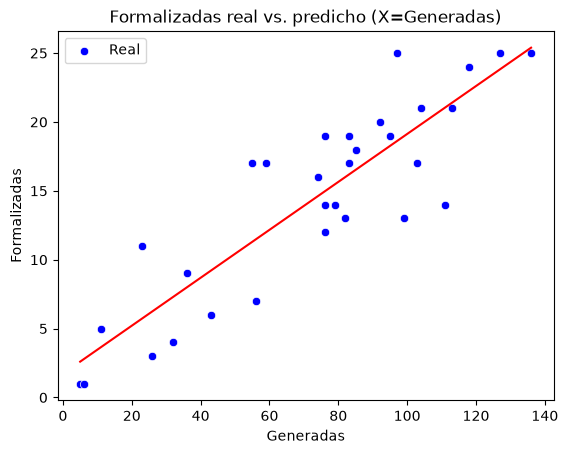

In [8]:
r2_sdc = model_sdc.score(Vars_Indep, Var_Dep)
print("R²:", r2_sdc)

y_pred = model_sdc.predict(X=Vars_Indep)
dfs['Predicciones_Formalizadas'] = y_pred

sns.scatterplot(x='Generadas', y='Formalizadas', color="blue", data=dfs, label='Real')
sns.lineplot(x='Generadas', y='Predicciones_Formalizadas', color="red", data=dfs)
plt.title('Formalizadas real vs. predicho (X=Generadas)')
plt.legend()

### 9. Coeficiente de correlación

In [9]:
coef_correl_sdc = np.sqrt(r2_sdc)
coef_correl_sdc

np.float64(0.8805813368169112)